Langkah 1
1. Buat folder di google drive
2. Menghubungkan google drive ke colab
3. Load dataset dari google drive
4. Cek dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/ecommerce-sales-analysis/data/raw/'

orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')
products = pd.read_csv(base_path + 'olist_products_dataset.csv')
payments = pd.read_csv(base_path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
sellers = pd.read_csv(base_path + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(base_path + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(base_path + 'product_category_name_translation.csv')

In [3]:
datasets = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'payments': payments,
    'reviews': reviews,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

orders: 99441 rows, 8 columns
order_items: 112650 rows, 7 columns
customers: 99441 rows, 5 columns
products: 32951 rows, 9 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
sellers: 3095 rows, 4 columns
geolocation: 1000163 rows, 5 columns
category_translation: 71 rows, 2 columns


Langkah 2 - Data Understanding
digunakan untuk memahami isi kolom, missing value, duplicate, dan relasi antar tabel

In [4]:
#Cek Kolom Setiap Dataset
for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print(df.columns.tolist())


ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

GEOLOCATION
['geolocation_zi

In [5]:
#Cek 5 Data Teratas Tiap Dataset
for name, df in datasets.items():
    print(f'\n{name.upper()}')
    display(df.head())


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



CUSTOMERS


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [6]:
#Cek Informasi Tipe Data
for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print(df.info())


ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

ORDER_ITEMS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id           

In [7]:
# Cek Missing Value
for name, df in datasets.items():
    print(f'\n{name.upper()}')
    missing = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100

    missing_table = pd.DataFrame({
        'missing_count': missing,
        'missing_percent': missing_percent.round(2)
    })

    display(missing_table[missing_table['missing_count'] > 0])


ORDERS


,missing_count,missing_percent
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98



ORDER_ITEMS


,missing_count,missing_percent



CUSTOMERS


...

,missing_count,missing_percent



GEOLOCATION


,missing_count,missing_percent



CATEGORY_TRANSLATION


,missing_count,missing_percent


In [8]:
# Cek Duplicate
for name, df in datasets.items():
    print(f'{name}: {df.duplicated().sum()} duplicated rows')

orders: 0 duplicated rows
order_items: 0 duplicated rows
customers: 0 duplicated rows
products: 0 duplicated rows
payments: 0 duplicated rows
reviews: 0 duplicated rows
sellers: 0 duplicated rows
geolocation: 261831 duplicated rows
category_translation: 0 duplicated rows


Langkah 3 - Data Cleaning

In [9]:
# Ubah Kolom Tanggal Menjadi Datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [10]:
# Menampilkan hasil
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [11]:
# Tambahkan Kolom Waktu
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_month_name'] = orders['order_purchase_timestamp'].dt.month_name()
orders['order_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [12]:
# Buat Kolom Delivery Time dan Late Delivery
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']
).dt.days

orders['is_late_delivery'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

In [13]:
# Menampilkan Hasil
orders[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date',
        'order_estimated_delivery_date', 'delivery_time_days',
        'estimated_delivery_days', 'is_late_delivery']].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,estimated_delivery_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,15,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,19,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,26,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,26,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,12,False


Langkah 4 - Merge Dataset Menjadi Master Table

In [14]:
# Merge Orders + Customers
ecommerce_df = orders.merge(customers, on='customer_id', how='left')

In [15]:
# Merge Orders + Order Items
ecommerce_df = ecommerce_df.merge(order_items, on='order_id', how='left')

In [16]:
# Merge Orders + Products
ecommerce_df = ecommerce_df.merge(products, on='product_id', how='left')

In [17]:
# Merge Orders + Category Translation
ecommerce_df = ecommerce_df.merge(category_translation, on ='product_category_name', how='left')

In [18]:
# Merge Orders + Sellers
ecommerce_df = ecommerce_df.merge(sellers, on='seller_id', how='left')

In [19]:
# Merge Orders + Reviews
ecommerce_df = ecommerce_df.merge(reviews, on='order_id', how='left')

In [20]:
# Payment Agregasi
payment_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_type': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
}).reset_index()

In [21]:
# Merge Orders + Payment
ecommerce_df = ecommerce_df.merge(payment_agg, on='order_id', how='left')

In [22]:
# Cek Hasil
ecommerce_df.shape

(114092, 46)

In [23]:
# Cek Hasil
ecommerce_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_value,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,38.71,1.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,MG,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,28.62,1.0,credit_card


In [24]:
# Cek Hasil
ecommerce_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_year',
 'order_month',
 'order_month_name',
 'order_year_month',
 'delivery_time_days',
 'estimated_delivery_days',
 'is_late_delivery',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'payment_value',
 'payment_installments',
 'paym

Langkah 5 - Merapikan Mater Dataset

In [25]:
selected_columns = [
    'order_id',
    'customer_id',
    'customer_unique_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_year',
    'order_month',
    'order_month_name',
    'order_year_month',
    'delivery_time_days',
    'estimated_delivery_days',
    'is_late_delivery',

    'customer_city',
    'customer_state',

    'order_item_id',
    'product_id',
    'product_category_name',
    'product_category_name_english',

    'seller_id',
    'seller_city',
    'seller_state',

    'price',
    'freight_value',
    'payment_type',
    'payment_installments',
    'payment_value',

    'review_score'
]

ecommerce_clean = ecommerce_df[selected_columns].copy()

ecommerce_clean.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,...,product_category_name_english,seller_id,seller_city,seller_state,price,freight_value,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,...,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,29.99,8.72,voucher,1.0,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,...,perfumery,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,118.70,22.76,boleto,1.0,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,...,auto,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,159.90,19.22,credit_card,3.0,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,...,pet_shop,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,45.00,27.20,credit_card,1.0,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,...,stationery,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,19.90,8.72,credit_card,1.0,28.62,5.0


Langkah 6 - Cek Missing Value Pada Master Dataset

In [26]:
missing = ecommerce_clean.isnull().sum()
missing_percent = (ecommerce_clean.isnull().sum() / len(ecommerce_clean)) * 100

missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent.round(2)
})

missing_table[missing_table['missing_count'] > 0].sort_values(by='missing_count', ascending=False)

,missing_count,missing_percent
order_delivered_customer_date,3253,2.85
delivery_time_days,3253,2.85
product_category_name_english,2414,2.12
product_category_name,2390,2.09
order_delivered_carrier_date,1980,1.74
review_score,961,0.84
seller_id,778,0.68
product_id,778,0.68
order_item_id,778,0.68
freight_value,778,0.68


Langkah 7 - Cleaning Data yang Tidak Diperlukan

In [27]:
ecommerce_clean['order_status'].value_counts()

,count
order_status,
delivered,110840
shipped,1197
canceled,711
unavailable,612
invoiced,366
processing,358
created,5
approved,3


In [28]:
ecommerce_clean = ecommerce_clean[ecommerce_clean['order_status'] == 'delivered'].copy()

ecommerce_clean.shape

(110840, 31)

Langkah 8 - Mengisi Missing Value Kategori Produk

In [29]:
ecommerce_clean['product_category_name'] = ecommerce_clean['product_category_name'].fillna('unknown')
ecommerce_clean['product_category_name_english'] = ecommerce_clean['product_category_name_english'].fillna('unknown')

Langkah 9 - Hapus Data Delivery Time yang Kosong

In [30]:
ecommerce_clean = ecommerce_clean.dropna(subset=[
    'order_delivered_customer_date',
    'delivery_time_days'
])

In [31]:
ecommerce_clean.isnull().sum()

,0
order_id,0
customer_id,0
customer_unique_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_year,0


In [32]:
ecommerce_clean = ecommerce_clean.dropna(subset=['review_score'])

In [33]:
ecommerce_clean.shape

(110005, 31)

In [34]:
ecommerce_clean.isnull().sum()

,0
order_id,0
customer_id,0
customer_unique_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_year,0


In [35]:
ecommerce_clean = ecommerce_clean.dropna()

In [36]:
ecommerce_clean.shape
ecommerce_clean.isnull().sum()

,0
order_id,0
customer_id,0
customer_unique_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_year,0


Langkah 10 - Buat Kolom Revenue

In [37]:
ecommerce_clean['total_sales'] = ecommerce_clean['price'] + ecommerce_clean['freight_value']

Langkah 11 - Cek Data Setelah Cleaning

In [38]:
ecommerce_clean.shape

(109986, 32)

In [39]:
ecommerce_clean.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,...,seller_id,seller_city,seller_state,price,freight_value,payment_type,payment_installments,payment_value,review_score,total_sales
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,...,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,29.99,8.72,voucher,1.0,38.71,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,...,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,118.70,22.76,boleto,1.0,141.46,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,...,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,159.90,19.22,credit_card,3.0,179.12,5.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,...,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,45.00,27.20,credit_card,1.0,72.20,5.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,...,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,19.90,8.72,credit_card,1.0,28.62,5.0,28.62


In [40]:
ecommerce_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109986 entries, 0 to 114091
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109986 non-null  object        
 1   customer_id                    109986 non-null  object        
 2   customer_unique_id             109986 non-null  object        
 3   order_status                   109986 non-null  object        
 4   order_purchase_timestamp       109986 non-null  datetime64[ns]
 5   order_approved_at              109986 non-null  datetime64[ns]
 6   order_delivered_carrier_date   109986 non-null  datetime64[ns]
 7   order_delivered_customer_date  109986 non-null  datetime64[ns]
 8   order_estimated_delivery_date  109986 non-null  datetime64[ns]
 9   order_year                     109986 non-null  int32         
 10  order_month                    109986 non-null  int32         
 11  order

Langkah 12 - Simpan Dataset Bersih ke Google Drive

In [41]:
import os

processed_path = '/content/drive/MyDrive/ecommerce-sales-analysis/data/processed/'
os.makedirs(processed_path, exist_ok=True)

In [42]:
ecommerce_clean.to_csv(processed_path + 'ecommerce_clean.csv', index=False)

In [43]:
import os

os.listdir(processed_path)

['ecommerce_clean.csv']

Langkah 13 - EDA: Business KPI

In [45]:
# Total Revenue
total_revenue = ecommerce_clean['total_sales'].sum()
total_revenue
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 15,357,574.15


In [47]:
# Total Orders
total_orders = ecommerce_clean['order_id'].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 95,808


In [49]:
# Total Customer
total_customers = ecommerce_clean['customer_unique_id'].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 92,732


In [54]:
# Average Order Value
avg_order_value = total_revenue / total_orders
print(f"Average Order Value: {avg_order_value:,.2f}")

Average Order Value: 160.30


In [55]:
# Average Review Score
avg_review_score = ecommerce_clean['review_score'].mean()
print(f"Average Review Score: {avg_order_value:,.2f}")

Average Review Score: 160.30


In [56]:
# Average Delivery Time
avg_delivery_time = ecommerce_clean['delivery_time_days'].mean()
print(f"Average Delivery Time: {avg_delivery_time:,.2f}")

Average Delivery Time: 11.97


In [57]:
# Late Delivery Rate
late_delivery_rate = ecommerce_clean['is_late_delivery'].mean() * 100
print(f"Late Delivery Rate: {late_delivery_rate:,.2f}%")

Late Delivery Rate: 7.78%


In [60]:
# Menggabungkan Semua KPI Card
kpi_summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Orders', 'Total Customers', 'Average Order Value', 'Average Review Score', 'Average Delivery Time', 'Late Delivery Rate'],
    'Value': [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        round(avg_order_value, 2),
        round(avg_review_score, 2),
        round(avg_delivery_time, 2),
        round(late_delivery_rate, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,15357574.15
1,Total Orders,95808.00
2,Total Customers,92732.00
3,Average Order Value,160.30
4,Average Review Score,4.08
5,Average Delivery Time,11.97
6,Late Delivery Rate,7.78


In [61]:
kpi_summary.to_csv(processed_path + 'kpi_summary.csv', index=False)

Langkah 14 - Analisis Revenue Tiap Bulan & Visualisasi

In [64]:
# Analisis Revenue
monthly_revenue = ecommerce_clean.groupby('order_year_month').agg({
    'total_sales': 'sum',
    'order_id': 'nunique',
    'customer_unique_id': 'nunique'
}).reset_index()

monthly_revenue.columns = [
    'order_year_month',
    'total_revenue',
    'total_orders',
    'total_customers'
]

monthly_revenue.head()

,order_year_month,total_revenue,total_orders,total_customers
0,2016-10,45851.52,262,259
1,2016-12,19.62,1,1
2,2017-01,127042.05,739,707
3,2017-02,269401.41,1631,1608
4,2017-03,409893.44,2527,2489


In [87]:
import os

image_path = '/content/drive/MyDrive/ecommerce-sales-analysis/images/'
os.makedirs(image_path, exist_ok=True)

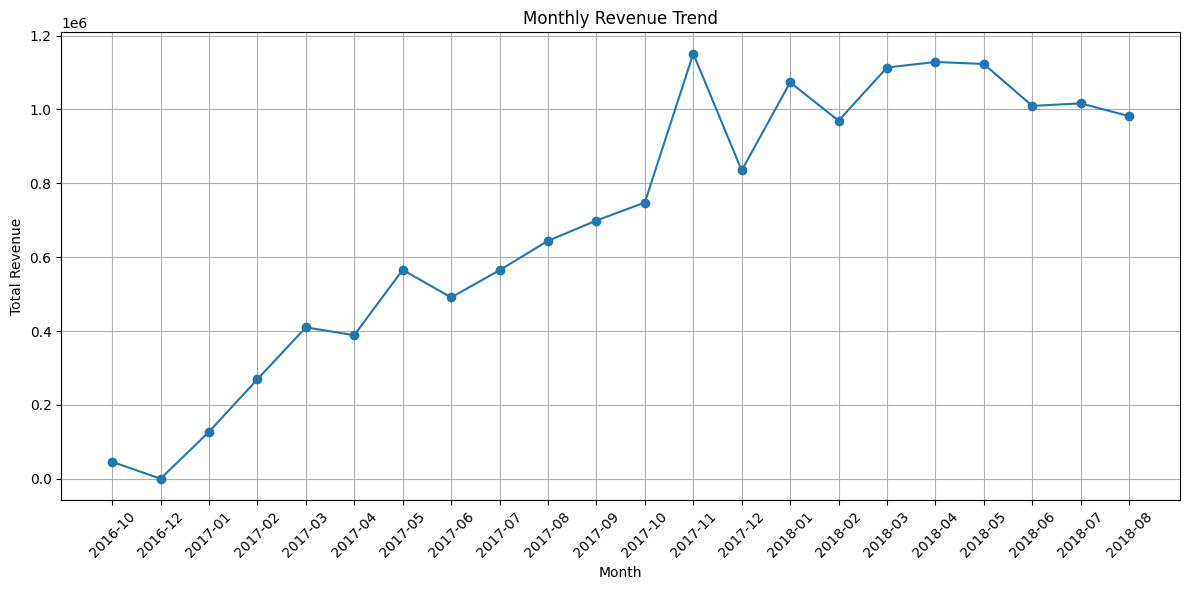

In [88]:
# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['order_year_month'], monthly_revenue['total_revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecommerce-sales-analysis/images/monthly_revenue_trend.png', dpi=300)
plt.show()

In [89]:
monthly_revenue.to_csv(processed_path + 'monthly_revenue.csv', index=False)

Langkah 15 - Analisis Top Kategori Produk & Visualisasi

In [67]:
top_categories = ecommerce_clean.groupby('product_category_name_english').agg({
    'total_sales': 'sum',
    'order_id': 'nunique',
    'review_score': 'mean'
}).reset_index()

top_categories.columns = [
    'product_category',
    'total_revenue',
    'total_orders',
    'avg_review_score'
]

top_categories = top_categories.sort_values(by='total_revenue', ascending=False)

top_categories.head(10)

,product_category,total_revenue,total_orders,avg_review_score
43,health_beauty,1407588.44,8600,4.191791
71,watches_gifts,1257539.51,5452,4.071613
7,bed_bath_table,1229290.14,9176,3.921067
65,sports_leisure,1117364.56,7483,4.166252
15,computers_accessories,1036574.85,6498,3.985139
39,furniture_decor,880220.95,6256,3.949969
49,housewares,756309.97,5709,4.108407
20,cool_stuff,685687.39,3528,4.194317
5,auto,662580.04,3791,4.116132
42,garden_tools,564637.72,3427,4.081119


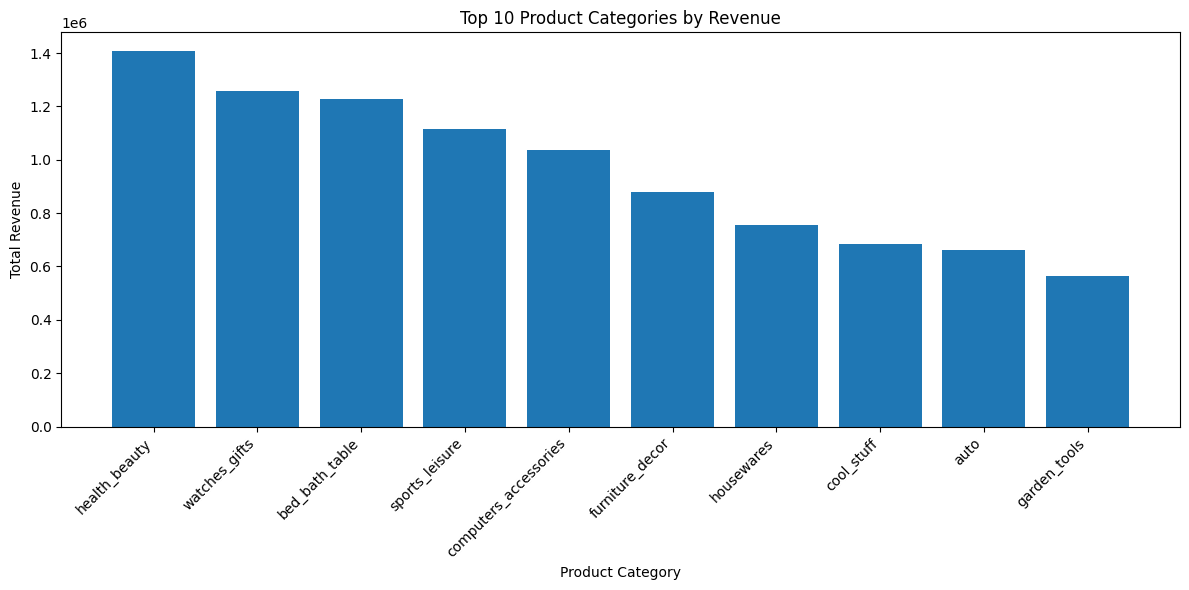

In [90]:
top_10_categories = top_categories.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_categories['product_category'], top_10_categories['total_revenue'])
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(image_path + 'top_product_categories.png', dpi=300)
plt.show()

In [91]:
top_categories.to_csv(processed_path + 'top_categories.csv', index=False)

Langkah 16 - Pemetaan Jumlah Pelanggan Berdasarkan Wilayah & Visualisasi

In [70]:
customer_by_state = ecommerce_clean.groupby('customer_state').agg({
    'customer_unique_id' : 'nunique',
    'order_id' : 'nunique',
    'total_sales' : 'sum'
}).reset_index()

customer_by_state.columns = [
    'customer_state',
    'total_customers',
    'total_orders',
    'total_revenue'
]

customer_by_state = customer_by_state.sort_values(by='total_customers', ascending=False)

customer_by_state.head(10)

,customer_state,total_customers,total_orders,total_revenue
25,SP,38927,40259,5765000.00
18,RJ,11788,12209,2034280.62
10,MG,10933,11282,1811438.64
22,RS,5148,5324,862175.65
17,PR,4748,4900,782745.65
23,SC,3423,3519,588371.43
4,BA,3132,3229,589223.13
6,DF,2009,2070,347244.68
7,ES,1905,1969,306222.40
8,GO,1884,1946,333498.43


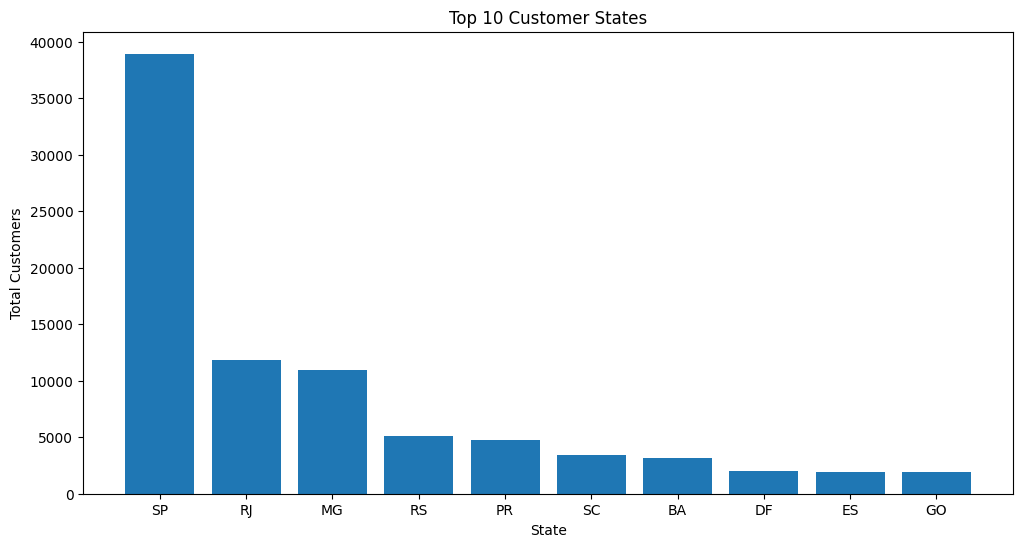

In [71]:
top_customer_states = customer_by_state.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_customer_states['customer_state'], top_customer_states['total_customers'])
plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Total Customers')
plt.show()

In [72]:
customer_by_state.to_csv(processed_path + 'customer_by_state.csv', index=False)

Langkah 17 - Analisis Metode Pembayaran & Visualisasi

In [74]:
payment_analysis = ecommerce_clean.groupby('payment_type').agg({
    'order_id' : 'nunique',
    'customer_unique_id' : 'nunique',
    'total_sales' : 'sum',
    'payment_value' : 'sum',
    'review_score' : 'mean'
}).reset_index()

payment_analysis.columns = [
    'payment_type',
    'total_orders',
    'total_customers',
    'total_sales',
    'total_payment_value',
    'avg_review_score'
]

payment_analysis = payment_analysis.sort_values(by='total_orders', ascending=False)

payment_analysis

,payment_type,total_orders,total_customers,total_sales,total_payment_value,avg_review_score
1,credit_card,73438,71220,12182632.25,15249730.41,4.081993
0,boleto,19048,18581,2756381.32,3925614.42,4.073381
3,voucher,1845,1790,210269.52,244505.96,4.034517
2,debit_card,1477,1462,208291.06,246771.09,4.211736


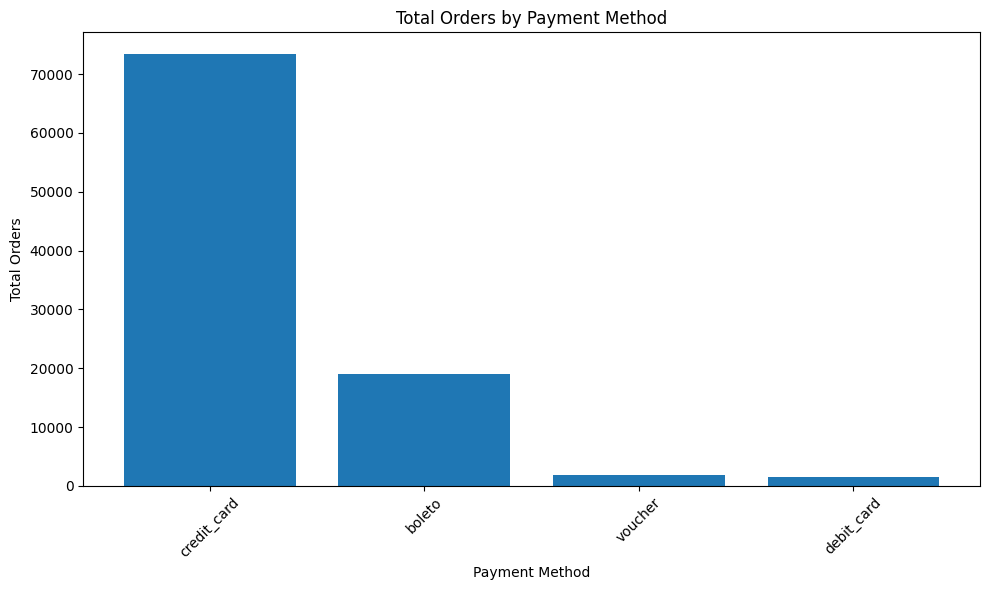

In [92]:
plt.figure(figsize=(10, 6))
plt.bar(payment_analysis['payment_type'], payment_analysis['total_orders'])
plt.title('Total Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(image_path + 'payment_method_orders.png', dpi=300)
plt.show()

In [93]:
payment_analysis.to_csv(processed_path + 'payment_analysis.csv', index=False)

Langkah 18 - Analisis Pengiriman Terlambat & Visualisai

In [77]:
delivery_analysis = ecommerce_clean.groupby('is_late_delivery').agg({
    'order_id': 'nunique',
    'customer_unique_id': 'nunique',
    'delivery_time_days': 'mean',
    'review_score': 'mean',
    'total_sales': 'sum'
}).reset_index()

delivery_analysis.columns = [
    'is_late_delivery',
    'total_orders',
    'total_customers',
    'avg_delivery_time_days',
    'avg_review_score',
    'total_sales'
]

delivery_analysis

,is_late_delivery,total_orders,total_customers,avg_delivery_time_days,avg_review_score,total_sales
0,False,88149,85424,10.385517,4.210569,14040054.91
1,True,7659,7606,30.733637,2.549088,1317519.24


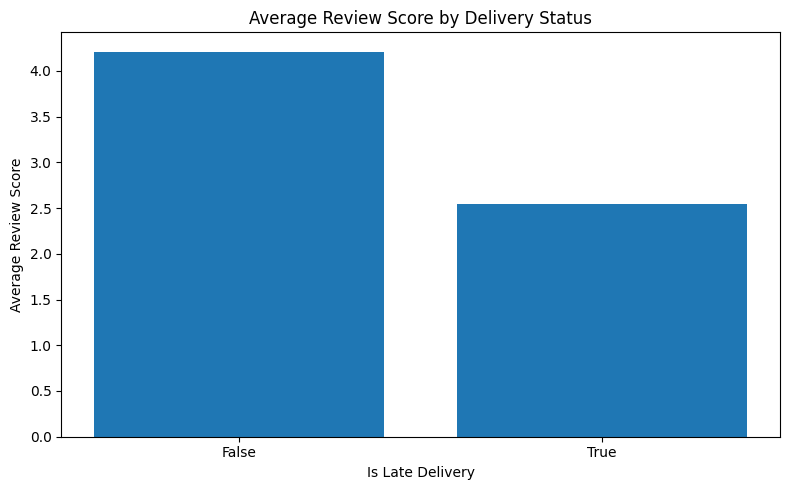

In [94]:
plt.figure(figsize=(8, 5))
plt.bar(delivery_analysis['is_late_delivery'].astype(str), delivery_analysis['avg_review_score'])
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Is Late Delivery')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.savefig(image_path + 'delivery_vs_review_score.png', dpi=300)
plt.show()

In [95]:
delivery_analysis.to_csv(processed_path + 'delivery_analysis.csv', index=False)

Langkah 19 - Analisis Rating Pelanggan & Visualisasi

In [80]:
review_distribution = ecommerce_clean.groupby('review_score').agg({
    'order_id': 'nunique',
    'customer_unique_id': 'nunique'
}).reset_index()

review_distribution.columns = [
    'review_score',
    'total_orders',
    'total_customers'
]

review_distribution

,review_score,total_orders,total_customers
0,1.0,9379,9245
1,2.0,2937,2901
2,3.0,7941,7837
3,4.0,18939,18642
4,5.0,56801,55171


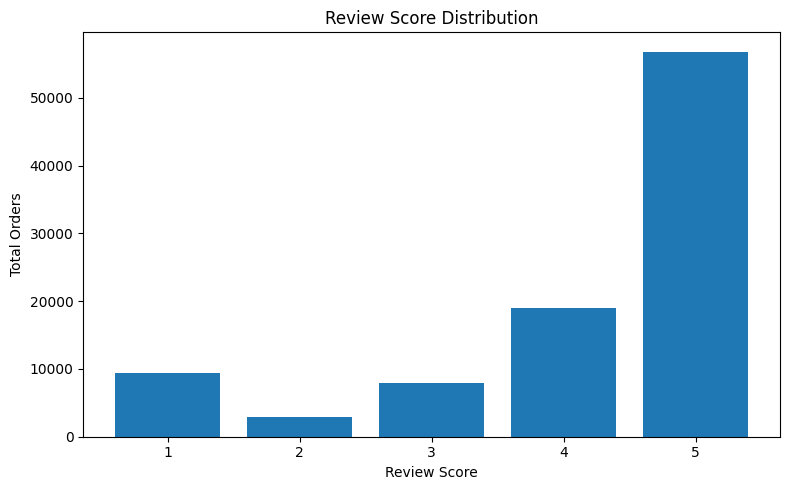

In [96]:
plt.figure(figsize=(8, 5))
plt.bar(review_distribution['review_score'], review_distribution['total_orders'])
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.savefig(image_path + 'review_score_distribution.png', dpi=300)
plt.show()

In [97]:
review_distribution.to_csv(processed_path + 'review_distribution.csv', index=False)

Langkah 20 - Analisis Kategori Produk Revenue Tinggi Tetapi Rating Rendah

In [83]:
category_risk = ecommerce_clean.groupby('product_category_name_english').agg({
    'total_sales': 'sum',
    'order_id': 'nunique',
    'review_score': 'mean'
}).reset_index()

category_risk.columns = [
    'product_category',
    'total_revenue',
    'total_orders',
    'avg_review_score'
]

category_risk = category_risk[
    (category_risk['total_orders'] >= 100) &
    (category_risk['avg_review_score'] < ecommerce_clean['review_score'].mean())
]

category_risk = category_risk.sort_values(by='total_revenue', ascending=False)

category_risk.head(10)

,product_category,total_revenue,total_orders,avg_review_score
71,watches_gifts,1257539.51,5452,4.071613
7,bed_bath_table,1229290.14,9176,3.921067
15,computers_accessories,1036574.85,6498,3.985139
39,furniture_decor,880220.95,6256,3.949969
42,garden_tools,564637.72,3427,4.081119
6,baby,463617.78,2787,4.079205
68,telephony,376911.85,4068,3.995007
57,office_furniture,333173.58,1244,3.517428
70,unknown,202890.12,1401,3.933076
26,electronics,196378.96,2498,4.067503


In [84]:
category_risk.to_csv(processed_path + 'category_risk.csv', index=False)

Langkah 21 - Analisis Pengiriman Lama dan Rating Rendah

In [85]:
delivery_by_state = ecommerce_clean.groupby('customer_state').agg({
    'order_id': 'nunique',
    'customer_unique_id': 'nunique',
    'delivery_time_days': 'mean',
    'is_late_delivery': 'mean',
    'review_score': 'mean',
    'total_sales': 'sum'
}).reset_index()

delivery_by_state.columns = [
    'customer_state',
    'total_orders',
    'total_customers',
    'avg_delivery_time_days',
    'late_delivery_rate',
    'avg_review_score',
    'total_revenue'
]

delivery_by_state['late_delivery_rate'] = delivery_by_state['late_delivery_rate'] * 100

delivery_by_state = delivery_by_state.sort_values(by='avg_delivery_time_days', ascending=False)

delivery_by_state.head(10)

,customer_state,total_orders,total_customers,avg_delivery_time_days,late_delivery_rate,avg_review_score,total_revenue
21,RR,41,40,27.826087,10.869565,3.891304,9039.52
3,AP,66,65,27.712500,5.000000,4.262500,16071.43
2,AM,144,139,25.865031,4.294479,4.092025,27573.10
1,AL,394,384,23.906542,23.598131,3.815421,92912.25
13,PA,933,911,23.054755,11.335255,3.842459,208438.68
9,MA,711,694,21.003759,19.799499,3.765664,147140.00
24,SE,334,328,20.833780,15.817694,3.898123,69140.25
5,CE,1272,1251,20.465917,15.249473,3.866479,265980.35
0,AC,80,76,20.329670,3.296703,4.131868,19575.33
14,PB,512,499,19.953528,11.015491,4.039587,136055.53


In [86]:
delivery_by_state.to_csv(processed_path + 'delivery_by_state.csv', index=False)

## Key Business Insights

1. Kartu kredit merupakan metode pembayaran yang paling dominan, dengan kontribusi tertinggi terhadap jumlah pesanan dan nilai transaksi.
2. Keterlambatan pengiriman memiliki dampak negatif yang kuat terhadap kepuasan pelanggan. Pesanan yang dikirim tepat waktu memiliki rata-rata review score sebesar 4.21, sedangkan pesanan yang terlambat hanya memiliki rata-rata review score sebesar 2.55.
3. Sebagian besar pelanggan merasa puas, ditunjukkan oleh review score 5 yang mendominasi distribusi ulasan. Namun, jumlah review score 1 masih cukup signifikan dan perlu dianalisis lebih lanjut.
4. Beberapa kategori produk dengan revenue tinggi memiliki review score di bawah rata-rata, seperti bed_bath_table, computers_accessories, furniture_decor, dan office_furniture.
5. Beberapa state seperti RR, AP, AM, AL, dan PA memiliki rata-rata waktu pengiriman yang jauh lebih lama dibandingkan rata-rata keseluruhan.

## Business Recommendations

1. Perusahaan perlu memprioritaskan perbaikan proses logistik untuk mengurangi keterlambatan pengiriman, karena keterlambatan terbukti berkaitan kuat dengan rendahnya kepuasan pelanggan.
2. Perusahaan perlu mengevaluasi kategori produk dengan revenue tinggi tetapi rating rendah untuk mengidentifikasi masalah terkait kualitas produk, akurasi deskripsi produk, packaging, performa seller, atau pengalaman pengiriman.
3. Perusahaan perlu mengoptimalkan strategi pengiriman regional, terutama untuk state dengan rata-rata waktu pengiriman dan tingkat keterlambatan yang tinggi.
4. Perusahaan dapat memanfaatkan kartu kredit sebagai fokus utama dalam strategi promosi berbasis metode pembayaran karena kontribusinya paling besar terhadap total order dan revenue.
5. Perusahaan perlu menganalisis lebih lanjut pesanan dengan review score rendah untuk menemukan pola masalah berulang dan meningkatkan pengalaman pelanggan.